✅ Saved Figure 5: figure5_survivability.png
✅ Saved Figure 6: figure6_latency.png


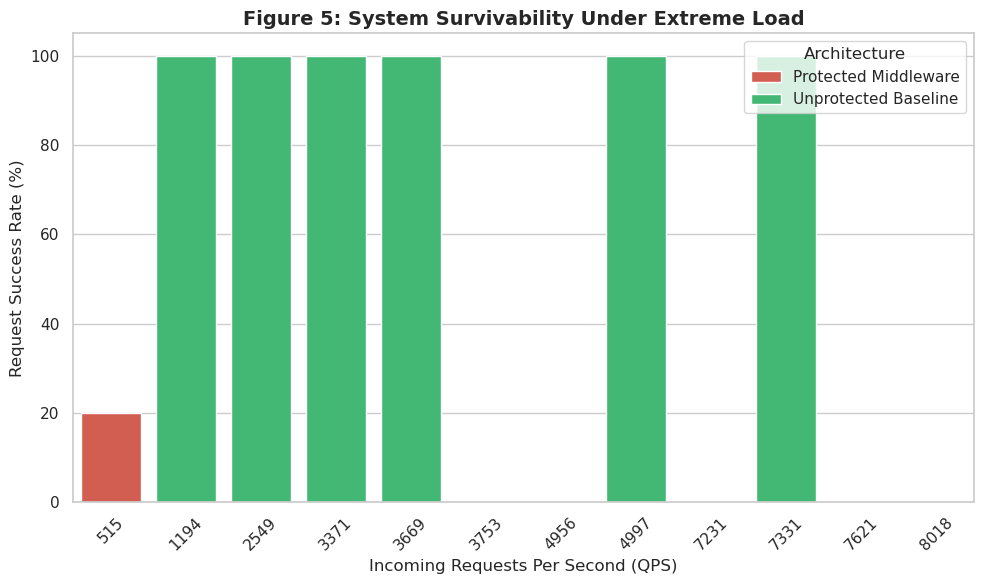

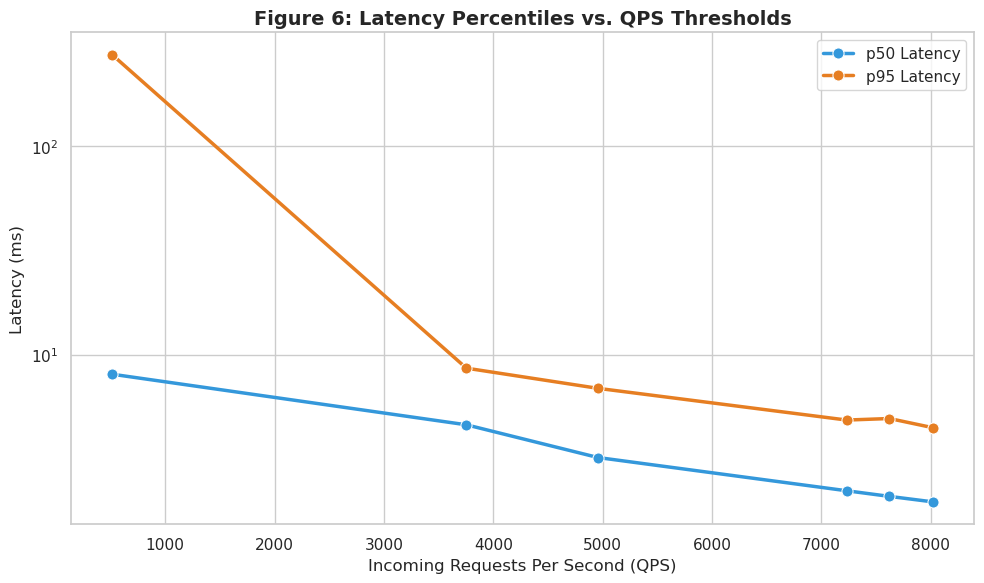

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data generated by your C++ load tester
try:
    df = pd.read_csv('combined_benchmark_results.csv')
except FileNotFoundError:
    print("Error: Could not find 'combined_benchmark_results.csv'. Make sure you run the C++ script first!")
    exit()

# Set the visual style to look clean and academic
sns.set_theme(style="whitegrid")

# ==========================================
# Figure 5: System Survivability (Success Rate)
# ==========================================
plt.figure(figsize=(10, 6))

# Create a bar chart comparing Success Rate across increasing load
sns.barplot(
    data=df, 
    x="QPS", 
    y="Success_Rate", 
    hue="Experiment", 
    palette=["#e74c3c", "#2ecc71"] # Red for Unprotected, Green for Protected
)

plt.title('Figure 5: System Survivability Under Extreme Load', fontsize=14, fontweight='bold')
# Format the X-axis labels to look cleaner (rounding QPS)
plt.xticks(ticks=range(len(df['QPS'].unique())), labels=[f"{int(q)}" for q in sorted(df['QPS'].unique())], rotation=45)
plt.xlabel('Incoming Requests Per Second (QPS)', fontsize=12)
plt.ylabel('Request Success Rate (%)', fontsize=12)
plt.legend(title='Architecture')
plt.tight_layout()

# Save to file
plt.savefig('figure5_survivability.png', dpi=300)
print("✅ Saved Figure 5: figure5_survivability.png")

# ==========================================
# Figure 6: Latency Percentiles vs. QPS
# ==========================================
plt.figure(figsize=(10, 6))

# Filter for just the Protected Middleware data to show the scaling curve
df_protected = df[df['Experiment'] == 'Protected Middleware'].copy()

# Sort by QPS so the lines connect sequentially
df_protected = df_protected.sort_values(by='QPS')

# Plot p50 Latency
sns.lineplot(
    data=df_protected, 
    x="QPS", 
    y="p50_Latency_ms", 
    color="#3498db", 
    label="p50 Latency",
    marker="o",
    markersize=8,
    linewidth=2.5
)

# Plot p95 Latency
sns.lineplot(
    data=df_protected, 
    x="QPS", 
    y="p95_Latency_ms", 
    color="#e67e22", 
    label="p95 Latency",
    marker="o",
    markersize=8,
    linewidth=2.5
)

plt.title('Figure 6: Latency Percentiles vs. QPS Thresholds', fontsize=14, fontweight='bold')
plt.xlabel('Incoming Requests Per Second (QPS)', fontsize=12)
plt.ylabel('Latency (ms)', fontsize=12)

# Set the Y-axis to logarithmic to better handle the initial cache-miss spike (274ms)
plt.yscale('log')
plt.legend()
plt.tight_layout()

# Save to file
plt.savefig('figure6_latency.png', dpi=300)
print("✅ Saved Figure 6: figure6_latency.png")